In [9]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu
CUDA available: False
Using device: cpu


In [10]:
import sys
from pathlib import Path

import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
CUDA available: False
Device: cpu


In [11]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Results:", RESULTS_DIR)

Project root: c:\SLIIT\4Y1S\SE4050 - DL\Project\Brain Tumour MRI Classification\brain-tumour-mri-classification
Data root: c:\SLIIT\4Y1S\SE4050 - DL\Project\Brain Tumour MRI Classification\brain-tumour-mri-classification\data
Results: c:\SLIIT\4Y1S\SE4050 - DL\Project\Brain Tumour MRI Classification\brain-tumour-mri-classification\results


In [12]:
sys.path.append(str(PROJECT_ROOT))

from src.dataset import get_dataloaders
from src.transforms import train_transforms, val_test_transforms
from src.utils import (
    evaluate_model,
    plot_confusion_matrix,
    plot_learning_curves,
    print_metrics
)

print("Shared project modules imported successfully.")

Shared project modules imported successfully.


In [13]:
BATCH_SIZE = 32
NUM_CLASSES = 4
IMAGE_SIZE = 224
SEED = 42

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("Batch size:", BATCH_SIZE)
print("Image size:", IMAGE_SIZE)
print("Classes:", CLASS_NAMES)
print("Seed:", SEED)

Batch size: 32
Image size: 224
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Seed: 42


In [14]:
train_loader, val_loader, test_loader = get_dataloaders(
    data_root=str(DATA_ROOT),
    batch_size=BATCH_SIZE
)

Train:      4,480 images
Validation: 1,120 images
Test:       1,600 images
Classes:    ['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
First labels: tensor([0, 0, 0, 0, 2, 3, 0, 2, 0, 1])


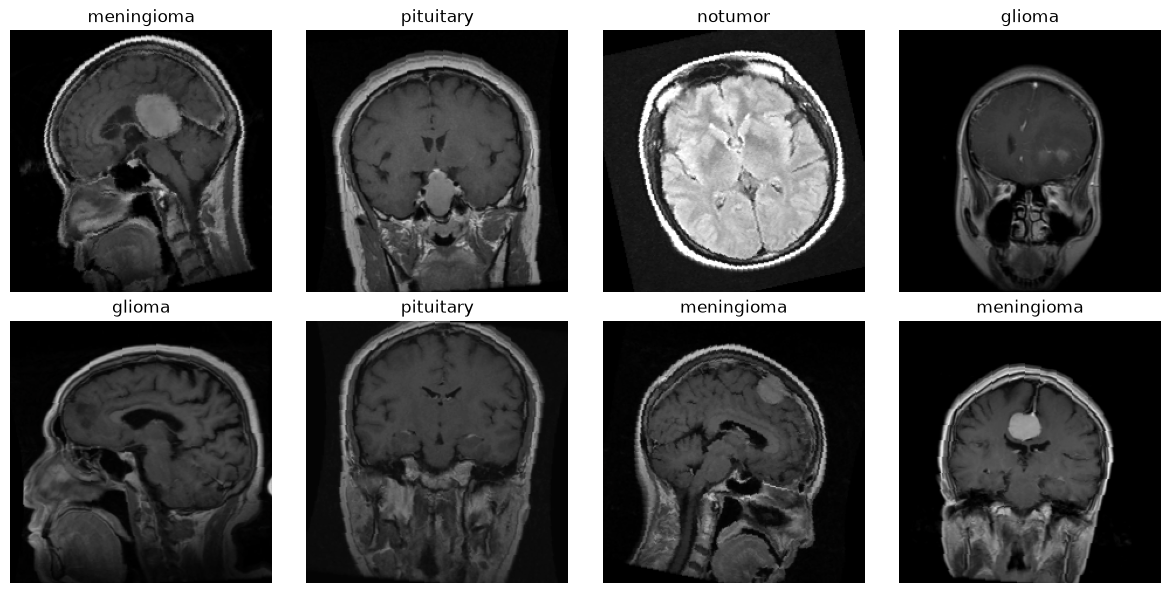

In [16]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1, 2, 0).cpu()

    image = image * std + mean
    image = image.clamp(0, 1)

    ax.imshow(image)
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

In [18]:
weights = VGG16_Weights.DEFAULT

model = vgg16(weights=weights)

print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [19]:
for param in model.features.parameters():
    param.requires_grad = False
    

In [20]:
model.classifier[6] = nn.Linear(
    in_features=4096,
    out_features=NUM_CLASSES
)

In [21]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cpu


In [22]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 134,276,932
Trainable parameters: 119,562,244


In [23]:
#PHASE 6 — Frozen VGG16 training

In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [26]:
def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [27]:
#PHASE 7 — First sanity training


In [28]:
EPOCHS = 2

In [29]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/2] Train Loss: 0.7877 Train Acc: 0.7473 Val Loss: 0.6129 Val Acc: 0.8027
Epoch [2/2] Train Loss: 0.5887 Train Acc: 0.8304 Val Loss: 0.3451 Val Acc: 0.8759


In [30]:
#PHASE 8 — Proper frozen training

In [31]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [32]:
#Cell 18 — Best model checkpoint
best_val_acc = 0.0
best_model_path = RESULTS_DIR / "VGG16_frozen_best.pth"

In [33]:
torch.save(model.state_dict(), best_model_path)

In [ ]:
#PHASE 9 — Learning curves

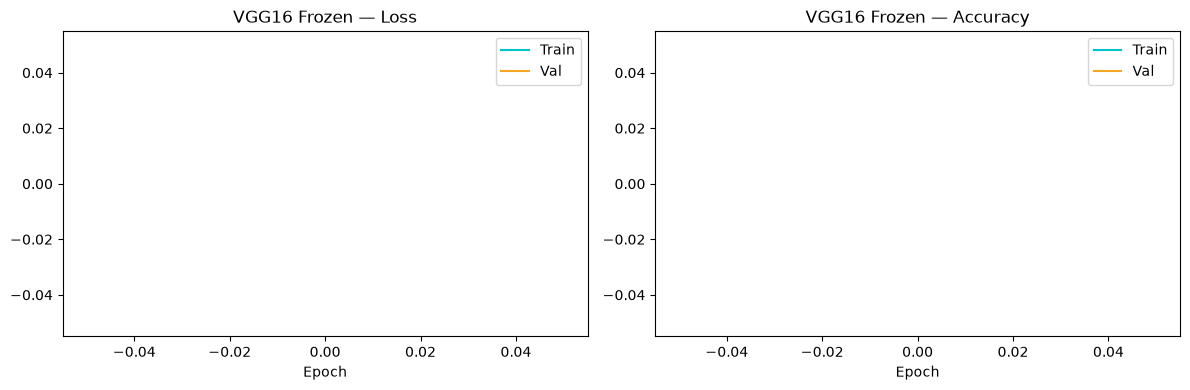

In [34]:
plot_learning_curves(
    train_losses,
    val_losses,
    train_accs,
    val_accs,
    model_name="VGG16 Frozen",
    save_path=RESULTS_DIR / "VGG16_frozen_learning_curves.png"
)

In [ ]:
#PHASE 10 — Frozen model validation metrics


In [35]:
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

<All keys matched successfully>

In [36]:
y_true, y_pred, y_probs = evaluate_model(
    model,
    val_loader,
    device,
    model_name="VGG16 Frozen"
)

In [37]:
print_metrics(
    y_true,
    y_pred,
    y_probs,
    "VGG16 Frozen"
)


Results for: VGG16 Frozen
              precision    recall  f1-score   support

      glioma       0.91      0.85      0.88       285
  meningioma       0.71      0.87      0.78       277
     notumor       1.00      0.83      0.91       289
   pituitary       0.95      0.96      0.95       269

    accuracy                           0.88      1120
   macro avg       0.89      0.88      0.88      1120
weighted avg       0.89      0.88      0.88      1120

ROC-AUC (OvR): 0.9787


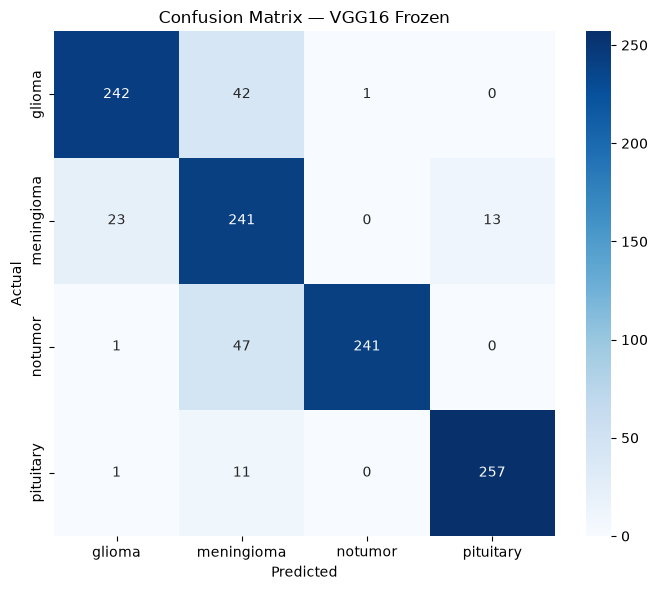

In [38]:
plot_confusion_matrix(
    y_true,
    y_pred,
    "VGG16 Frozen",
    save_path=RESULTS_DIR / "VGG16_frozen_confusion_matrix.png"
)

In [ ]:
#PHASE 11 — Fine-tuning
#Cell 19 — Unfreeze deeper layers

In [39]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[24:].parameters():
    param.requires_grad = True

In [40]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 126,641,668


In [41]:
#PHASE 12 — Fine-tuning optimizer

In [42]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [ ]:
#PHASE 13 — Fine-tune

In [43]:
EPOCHS = 25

In [44]:
train_losses_ft = []
val_losses_ft = []

train_accs_ft = []
val_accs_ft = []

In [45]:
#Save the best model:
best_ft_path = RESULTS_DIR / "VGG16_finetuned_best.pth"

In [46]:
if val_acc > best_val_acc:
    best_val_acc = val_acc

    torch.save(
        model.state_dict(),
        best_ft_path
    )

In [ ]:
#PHASE 14 — Compare the two VGG16 experiments
#PHASE 15 — Final test evaluation

In [47]:
model.load_state_dict(
    torch.load(
        best_ft_path,
        map_location=device
    )
)

<All keys matched successfully>

In [48]:
y_true, y_pred, y_probs = evaluate_model(
    model,
    test_loader,
    device,
    model_name="VGG16 Final"
)

In [49]:
print_metrics(
    y_true,
    y_pred,
    y_probs,
    "VGG16 Final"
)


Results for: VGG16 Final
              precision    recall  f1-score   support

      glioma       0.89      0.66      0.76       400
  meningioma       0.65      0.90      0.76       400
     notumor       0.97      0.88      0.92       400
   pituitary       0.96      0.95      0.95       400

    accuracy                           0.84      1600
   macro avg       0.87      0.84      0.85      1600
weighted avg       0.87      0.84      0.85      1600

ROC-AUC (OvR): 0.9624


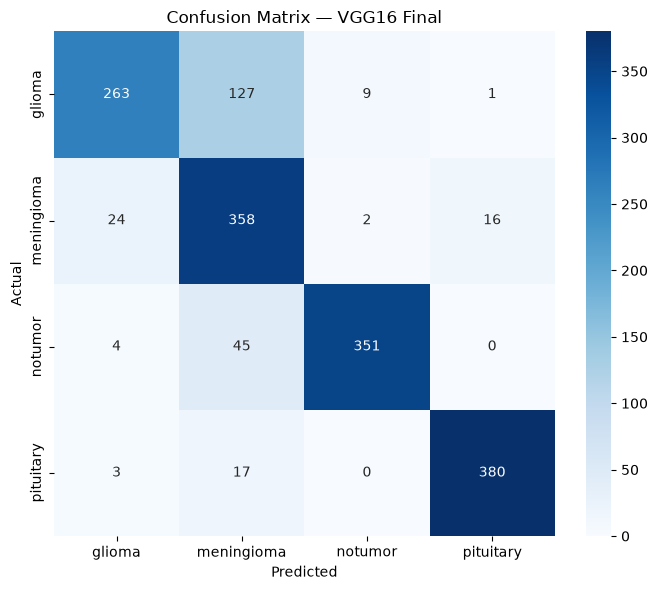

In [50]:
plot_confusion_matrix(
    y_true,
    y_pred,
    "VGG16 Final",
    save_path=RESULTS_DIR / "VGG16_final_confusion_matrix.png"
)

In [52]:
#PHASE 17 — ROC-AUC


In [55]:
##################################
print_metrics(
    y_true,
    y_pred,
    y_probs,
    "VGG16 Fine-Tuned"
)


Results for: VGG16 Fine-Tuned
              precision    recall  f1-score   support

      glioma       0.89      0.66      0.76       400
  meningioma       0.65      0.90      0.76       400
     notumor       0.97      0.88      0.92       400
   pituitary       0.96      0.95      0.95       400

    accuracy                           0.84      1600
   macro avg       0.87      0.84      0.85      1600
weighted avg       0.87      0.84      0.85      1600

ROC-AUC (OvR): 0.9624


In [ ]:
#PHASE 18 — Save the final model

In [56]:
FINAL_MODEL_PATH = RESULTS_DIR / "VGG16_final.pth"

torch.save(
    model.state_dict(),
    FINAL_MODEL_PATH
)

print("Saved:", FINAL_MODEL_PATH)

Saved: c:\SLIIT\4Y1S\SE4050 - DL\Project\Brain Tumour MRI Classification\brain-tumour-mri-classification\results\VGG16_final.pth


In [ ]:
#last call


In [57]:
#CAll 1
import sys
from pathlib import Path

import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
CUDA available: False
Device: cpu


In [58]:
#Call 2
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Results:", RESULTS_DIR)

Project root: c:\SLIIT\4Y1S\SE4050 - DL\Project\Brain Tumour MRI Classification\brain-tumour-mri-classification
Data root: c:\SLIIT\4Y1S\SE4050 - DL\Project\Brain Tumour MRI Classification\brain-tumour-mri-classification\data
Results: c:\SLIIT\4Y1S\SE4050 - DL\Project\Brain Tumour MRI Classification\brain-tumour-mri-classification\results


In [59]:
#Call 3
sys.path.append(str(PROJECT_ROOT))

from src.dataset import get_dataloaders
from src.transforms import train_transforms, val_test_transforms

print("Shared modules imported successfully.")

Shared modules imported successfully.


In [60]:
#Call 4
BATCH_SIZE = 32

train_loader, val_loader, test_loader = get_dataloaders(
    data_root=str(DATA_ROOT),
    batch_size=BATCH_SIZE
)

Train:      4,480 images
Validation: 1,120 images
Test:       1,600 images
Classes:    ['glioma', 'meningioma', 'notumor', 'pituitary']


In [61]:
#Call 5
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
First labels: tensor([0, 0, 3, 3, 3, 3, 3, 3, 0, 2])
